In [17]:
# Library imports and data handling
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# File paths configuration
RAW_DIR = Path(r"C:\Users\hamza\Downloads\PROJET-FULL-STACK-DATA\housing-mle\data\raw")
PROCESSED_DIR = Path(r"C:\Users\hamza\Downloads\PROJET-FULL-STACK-DATA\housing-mle\data\processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [18]:
# Load temporal splits (from notebook 00_data_split)
train_df = pd.read_csv(RAW_DIR / "train_raw.csv", parse_dates=["date"])
eval_df = pd.read_csv(RAW_DIR / "eval_raw.csv", parse_dates=["date"])
holdout_df = pd.read_csv(RAW_DIR / "holdout_raw.csv", parse_dates=["date"])

print(f"Data loaded - Train: {train_df.shape[0]:,} rows | Eval: {eval_df.shape[0]:,} rows | Holdout: {holdout_df.shape[0]:,} rows")

Data loaded - Train: 585,244 rows | Eval: 149,424 rows | Holdout: 149,424 rows


In [19]:
# Exploratory Data Analysis: initial checks
pd.set_option('display.max_columns', None)
print("\n=== Initial Data Overview ===")
print("Sample rows (first 2):")
print(train_df.head(2))

print("\nData types distribution:")
print(train_df.dtypes.value_counts())

print("\nMissing values (train):")
missing = train_df.isna().sum()
if missing.any():
    print(missing[missing > 0])
else:
    print("No missing values detected")

print("\nTarget variable statistics (price):")
print(train_df['price'].describe())


=== Initial Data Overview ===
Sample rows (first 2):
        date  median_sale_price  median_list_price  median_ppsf  \
0 2012-03-31            46550.0           217450.0    31.813674   
1 2012-03-31           200000.0             7500.0   104.931794   

   median_list_ppsf  homes_sold  pending_sales  new_listings  inventory  \
0        110.183666        14.0           23.0          44.0       64.0   
1         79.265873         1.0            1.0           1.0        2.0   

   median_dom  avg_sale_to_list  sold_above_list  off_market_in_two_weeks  \
0        59.5          0.943662         0.142857                 0.043478   
1       290.0          0.909091         0.000000                 0.000000   

  city  zipcode  year  bank  bus  hospital  mall  park  restaurant  school  \
0  ATL    30002  2012  12.0  2.0       4.0   1.0  60.0        45.0    57.0   
1  PGH    15469  2012   0.0  0.0       0.0   0.0   0.0         0.0     4.0   

   station  supermarket  Total Population  Median A

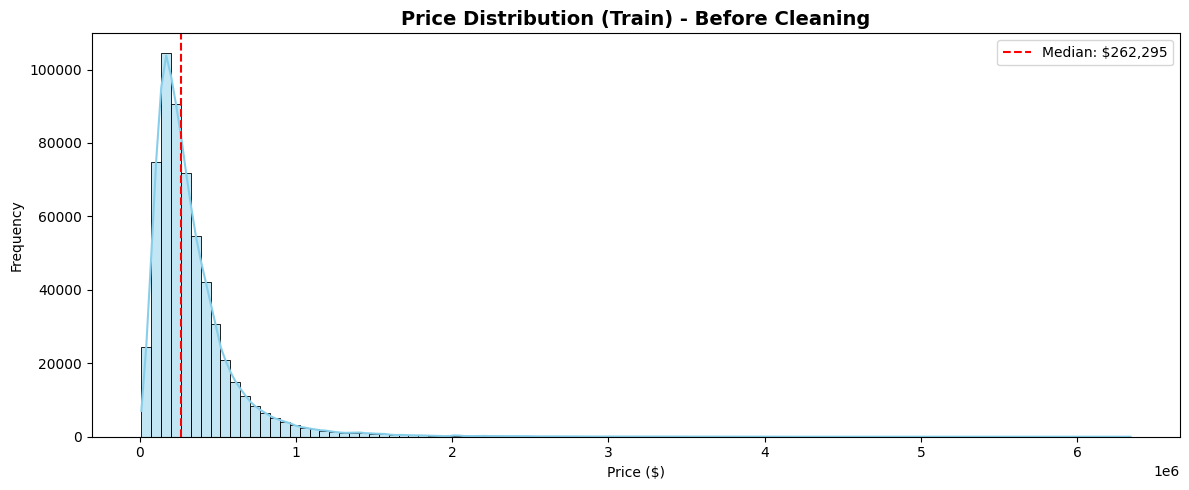

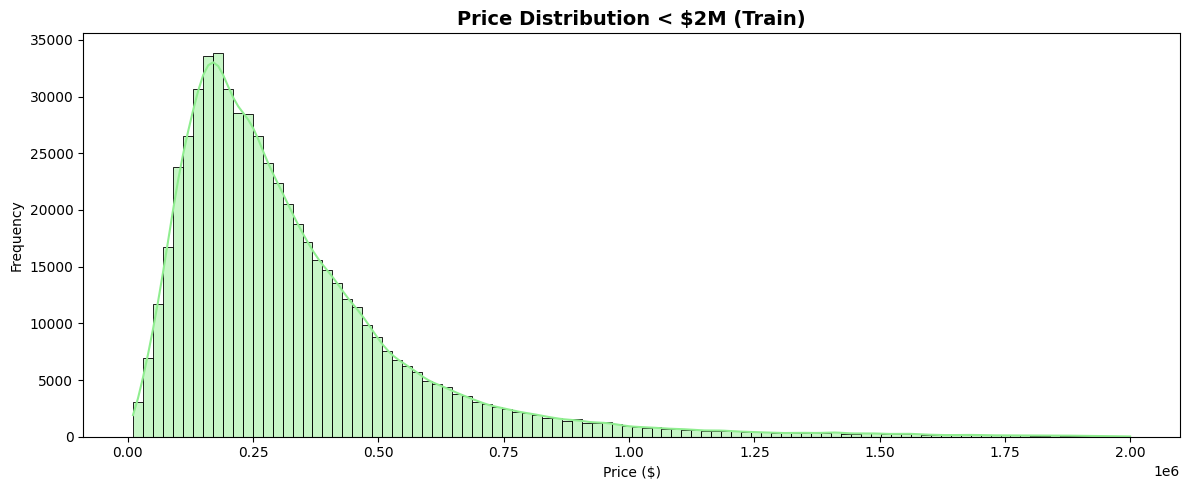

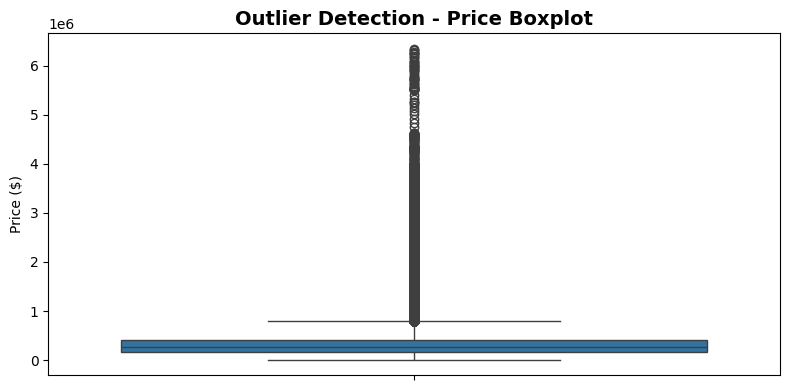

In [20]:
# Price distribution analysis (before cleaning)
plt.figure(figsize=(12, 5))
sns.histplot(train_df['price'], bins=100, kde=True, color='skyblue')
plt.title("Price Distribution (Train) - Before Cleaning", fontsize=14, fontweight='bold')
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.axvline(x=train_df['price'].median(), color='red', linestyle='--', label=f"Median: ${train_df['price'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.show()

# Zoomed view: prices < $2M (bulk of data)
plt.figure(figsize=(12, 5))
sns.histplot(train_df[train_df['price'] < 2_000_000]['price'], bins=100, kde=True, color='lightgreen')
plt.title("Price Distribution < $2M (Train)", fontsize=14, fontweight='bold')
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Visual outlier detection with boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(y=train_df['price'])
plt.title("Outlier Detection - Price Boxplot", fontsize=14, fontweight='bold')
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

In [21]:
# Remove exact duplicates across all splits
dup_train = train_df.duplicated().sum()
dup_eval = eval_df.duplicated().sum()
dup_holdout = holdout_df.duplicated().sum()

train_clean = train_df.drop_duplicates().copy()
eval_clean = eval_df.drop_duplicates().copy()
holdout_clean = holdout_df.drop_duplicates().copy()

print("Duplicate removal completed:")
print(f"  Train:   {len(train_clean):,} rows (removed {dup_train:,})")
print(f"  Eval:    {len(eval_clean):,} rows (removed {dup_eval:,})")
print(f"  Holdout: {len(holdout_clean):,} rows (removed {dup_holdout:,})")

Duplicate removal completed:
  Train:   585,244 rows (removed 0)
  Eval:    149,424 rows (removed 0)
  Holdout: 149,424 rows (removed 0)



Top 10 prices (train):
500138    $6,342,460
494993    $6,328,011
507054    $6,321,498
489863    $6,278,641
514284    $6,266,341
482761    $6,253,503
474367    $6,240,334
470613    $6,234,990
461490    $6,189,029
518587    $6,179,439
Name: price, dtype: object

99th percentile: $1,523,744

Outlier filtering (price > $1,500,000):
  Train:   579,123 rows (removed 6,121)
  Eval:    146,667 rows (removed 2,757)
  Holdout: 145,107 rows (removed 4,317)


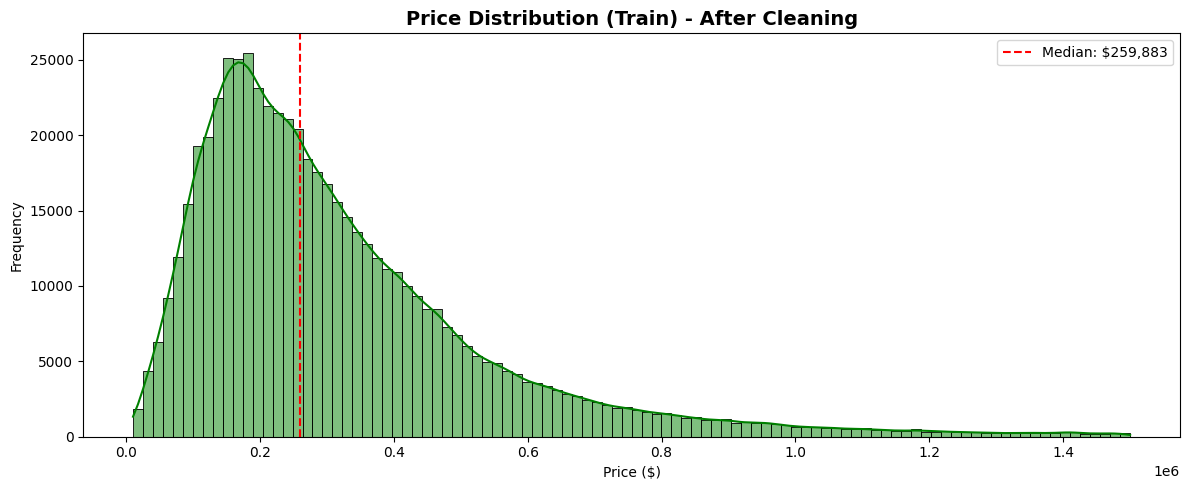

In [22]:
# Outlier detection: inspect high-end prices
print("\nTop 10 prices (train):")
print(train_clean['price'].sort_values(ascending=False).head(10).apply(lambda x: f"${x:,.0f}"))

# Define outlier threshold based on percentile
threshold_99 = train_clean['price'].quantile(0.99)
print(f"\n99th percentile: ${threshold_99:,.0f}")

# Remove outliers above threshold
OUTLIER_THRESHOLD = 1_500_000  # Adjusted based on visual inspection

train_filtered = train_clean[train_clean["price"] <= OUTLIER_THRESHOLD].copy()
eval_filtered = eval_clean[eval_clean["price"] <= OUTLIER_THRESHOLD].copy()
holdout_filtered = holdout_clean[holdout_clean["price"] <= OUTLIER_THRESHOLD].copy()

print(f"\nOutlier filtering (price > ${OUTLIER_THRESHOLD:,}):")
print(f"  Train:   {len(train_filtered):,} rows (removed {len(train_clean) - len(train_filtered):,})")
print(f"  Eval:    {len(eval_filtered):,} rows (removed {len(eval_clean) - len(eval_filtered):,})")
print(f"  Holdout: {len(holdout_filtered):,} rows (removed {len(holdout_clean) - len(holdout_filtered):,})")

# Verify cleaning effectiveness
plt.figure(figsize=(12, 5))
sns.histplot(train_filtered['price'], bins=100, kde=True, color='green')
plt.title("Price Distribution (Train) - After Cleaning", fontsize=14, fontweight='bold')
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.axvline(x=train_filtered['price'].median(), color='red', linestyle='--', label=f"Median: ${train_filtered['price'].median():,.0f}")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Load metro reference data once (used for all splits)
metros = pd.read_csv(RAW_DIR / "us_metros.csv")

# City name corrections for consistency with metros dataset
city_mapping = {
    "Las Vegas-Henderson-Paradise": "Las Vegas-Henderson-North Las Vegas",
    "Denver-Aurora-Lakewood": "Denver-Aurora-Centennial",
    "Houston-The Woodlands-Sugar Land": "Houston-Pasadena-The Woodlands",
    "Austin-Round Rock-Georgetown": "Austin-Round Rock-San Marcos",
    "Miami-Fort Lauderdale-Pompano Beach": "Miami-Fort Lauderdale-West Palm Beach",
    "San Francisco-Oakland-Berkeley": "San Francisco-Oakland-Fremont",
    "DC_Metro": "Washington-Arlington-Alexandria",
    "Atlanta-Sandy Springs-Alpharetta": "Atlanta-Sandy Springs-Roswell",
}

def merge_city_coords(df: pd.DataFrame, metros_ref: pd.DataFrame, mapping: dict) -> pd.DataFrame:
    """
    Merge city names with geographic coordinates from metros reference.
    
    Args:
        df: Input dataframe with 'city_full' column
        metros_ref: Reference dataframe with metro names and coordinates
        mapping: Dictionary of city name corrections
    
    Returns:
        Dataframe with added lat/lng columns
    """
    df = df.copy()
    
    # Apply city name corrections (map handles unmatched keys by returning NaN, fillna restores original)
    df["city_full"] = df["city_full"].map(mapping).fillna(df["city_full"])
    
    # Merge with metro coordinates (left join preserves all records)
    df = df.merge(
        metros_ref[["metro_full", "lat", "lng"]],
        how="left",
        left_on="city_full",
        right_on="metro_full"
    )
    
    # Drop redundant column and check for unmatched cities
    df = df.drop(columns=["metro_full"])
    missing = df[df["lat"].isna()]["city_full"].unique()
    
    if len(missing) > 0:
        print(f"Warning: {len(missing)} unmatched cities - {list(missing)[:5]}")
    else:
        print("SUCCESS: All cities matched with coordinates")
    
    return df

# Apply city-to-coordinates mapping for all splits
train_final = merge_city_coords(train_filtered, metros, city_mapping)
eval_final = merge_city_coords(eval_filtered, metros, city_mapping)
holdout_final = merge_city_coords(holdout_filtered, metros, city_mapping)

In [ ]:
# Save cleaned datasets with geographic features
train_final.to_csv(PROCESSED_DIR / "train_clean.csv", index=False)
eval_final.to_csv(PROCESSED_DIR / "eval_clean.csv", index=False)
holdout_final.to_csv(PROCESSED_DIR / "holdout_clean.csv", index=False)

print("\nData saved:")
print(f"  - {PROCESSED_DIR / 'train_clean.csv'}")
print(f"  - {PROCESSED_DIR / 'eval_clean.csv'}")
print(f"  - {PROCESSED_DIR / 'holdout_clean.csv'}")


Data saved:
  - C:\Users\hamza\Downloads\PROJET-FULL-STACK-DATA\housing-mle\data\processed\train_clean.csv
  - C:\Users\hamza\Downloads\PROJET-FULL-STACK-DATA\housing-mle\data\processed\eval_clean.csv
  - C:\Users\hamza\Downloads\PROJET-FULL-STACK-DATA\housing-mle\data\processed\holdout_clean.csv


: 